# 01. Data Exploration: Concrete Compressive Strength Dataset

**Objective:** Understand the dataset, explore sustainability implications, and prepare for ML modeling

**Contents:**
1. Dataset Loading & Overview
2. Statistical Analysis
3. Sustainability Metrics Exploration
4. Data Visualization
5. Correlation Analysis
6. Feature Engineering Ideas
7. Key Insights & Next Steps

## 1. Setup & Dataset Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load the enriched dataset
data_path = Path('../data/processed/concrete_enriched.csv')

if not data_path.exists():
    print("Dataset not found! Please run:")
    print("  python src/data/download_dataset.py")
else:
    df = pd.read_csv(data_path)
    print(f"✓ Dataset loaded: {df.shape[0]} instances, {df.shape[1]} features")

✓ Dataset loaded: 1030 instances, 17 features


## 2. Dataset Overview

In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength,recycled_content_kg,total_binder,recycled_content_pct,water_cement_ratio,cement_intensity,circularity_score,sustainability_grade,estimated_co2_kg_per_m3
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0.0,540.0,0.0,0.30,6.75,35.6,Medium,486.00
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0.0,540.0,0.0,0.30,8.72,34.3,Medium,486.00
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,142.5,475.0,30.0,0.69,8.26,59.1,High,306.38
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,142.5,475.0,30.0,0.69,8.10,59.2,High,306.38
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,132.4,331.0,40.0,0.97,4.48,69.7,High,185.36


In [4]:
# Data types and info
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cement                   1030 non-null   float64
 1   slag                     1030 non-null   float64
 2   fly_ash                  1030 non-null   float64
 3   water                    1030 non-null   float64
 4   superplasticizer         1030 non-null   float64
 5   coarse_aggregate         1030 non-null   float64
 6   fine_aggregate           1030 non-null   float64
 7   age                      1030 non-null   int64  
 8   strength                 1030 non-null   float64
 9   recycled_content_kg      1030 non-null   float64
 10  total_binder             1030 non-null   float64
 11  recycled_content_pct     1030 non-null   float64
 12  water_cement_ratio       1030 non-null   float64
 13  cement_intensity         1030 non-null   float64
 14  cir

In [5]:
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✓ No missing values!")

Missing Values:
sustainability_grade    1
dtype: int64


In [6]:
# Basic statistics
print("Statistical Summary:")
df.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.17,104.51,102.00,192.38,272.90,350.00,540.00
slag,1030.0,73.90,86.28,0.00,0.00,22.00,142.95,359.40
fly_ash,1030.0,54.19,64.00,0.00,0.00,0.00,118.30,200.10
water,1030.0,181.57,21.35,121.80,164.90,185.00,192.00,247.00
superplasticizer,1030.0,6.20,5.97,0.00,0.00,6.40,10.20,32.20
coarse_aggregate,1030.0,972.92,77.75,801.00,932.00,968.00,1029.40,1145.00
fine_aggregate,1030.0,773.58,80.18,594.00,730.95,779.50,824.00,992.60
age,1030.0,45.66,63.17,1.00,7.00,28.00,56.00,365.00
strength,1030.0,35.82,16.71,2.33,23.71,34.45,46.14,82.60
recycled_content_kg,1030.0,128.08,89.25,0.00,94.10,124.45,186.85,382.00


## 3. Sustainability Metrics Analysis

In [7]:
# Focus on sustainability columns
sustainability_cols = [
    'recycled_content_pct', 
    'circularity_score', 
    'sustainability_grade',
    'estimated_co2_kg_per_m3',
    'cement_intensity'
]

print("Sustainability Metrics Summary:")
print("="*60)
print(f"Average Recycled Content: {df['recycled_content_pct'].mean():.2f}%")
print(f"Max Recycled Content: {df['recycled_content_pct'].max():.2f}%")
print(f"Average Circularity Score: {df['circularity_score'].mean():.2f}/100")
print(f"Average CO2 Emissions: {df['estimated_co2_kg_per_m3'].mean():.2f} kg/m³")
print(f"Average Cement Intensity: {df['cement_intensity'].mean():.2f} kg/MPa")
print("="*60)

# Grade distribution
print("\nSustainability Grade Distribution:")
print(df['sustainability_grade'].value_counts())

Sustainability Metrics Summary:
Average Recycled Content: 30.97%
Max Recycled Content: 73.60%
Average Circularity Score: 59.03/100
Average CO2 Emissions: 259.46 kg/m³
Average Cement Intensity: 9.55 kg/MPa

Sustainability Grade Distribution:
sustainability_grade
High         463
Excellent    291
Medium       206
Low           69
Name: count, dtype: int64


## 4. Data Visualization

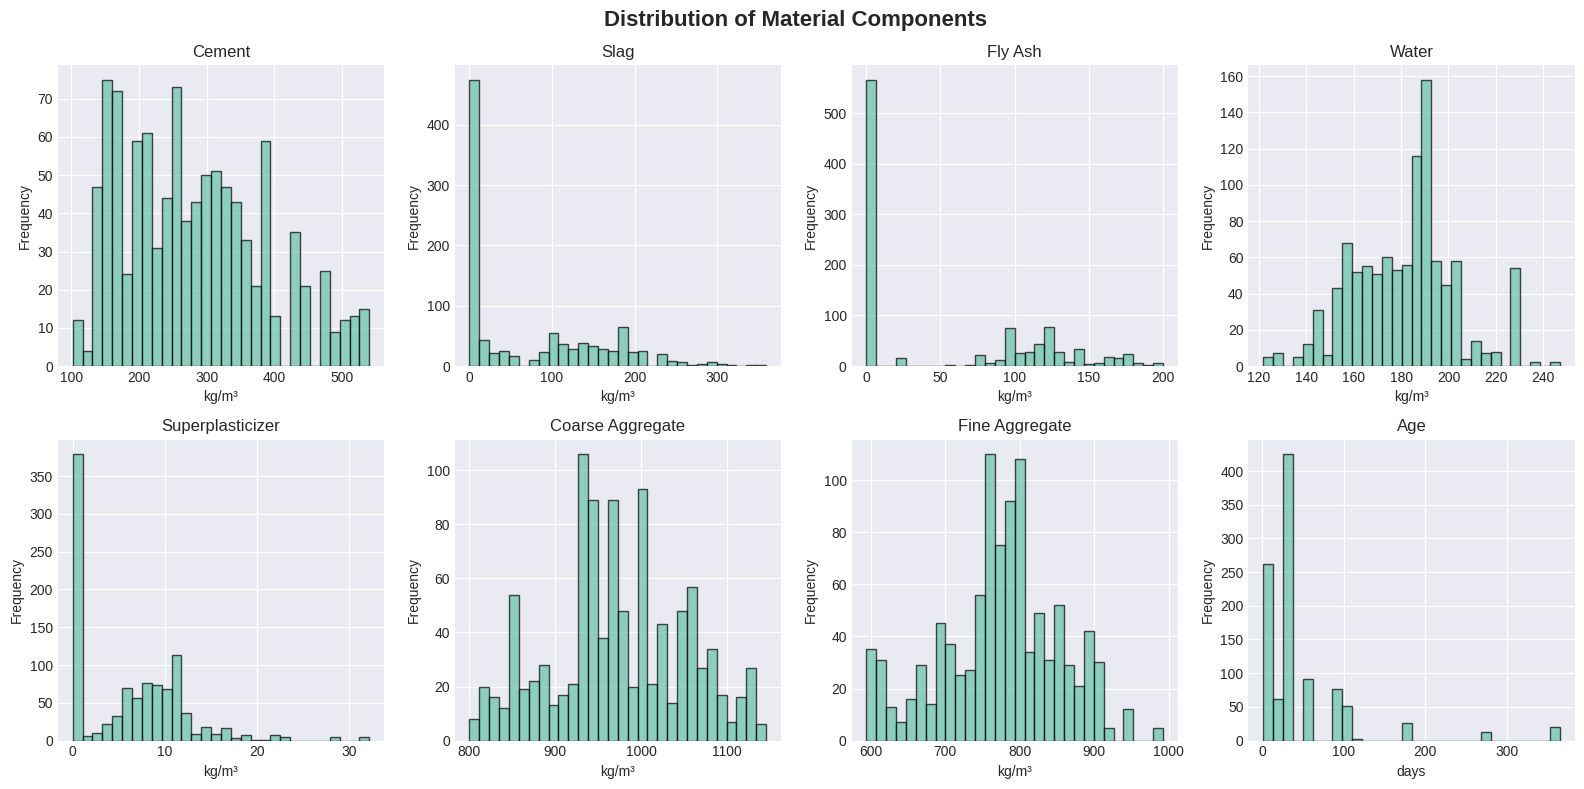

In [8]:
# Material composition distribution
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribution of Material Components', fontsize=16, fontweight='bold')

materials = ['cement', 'slag', 'fly_ash', 'water', 
             'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age']

for idx, col in enumerate(materials):
    ax = axes[idx // 4, idx % 4]
    ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('kg/m³' if col != 'age' else 'days')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

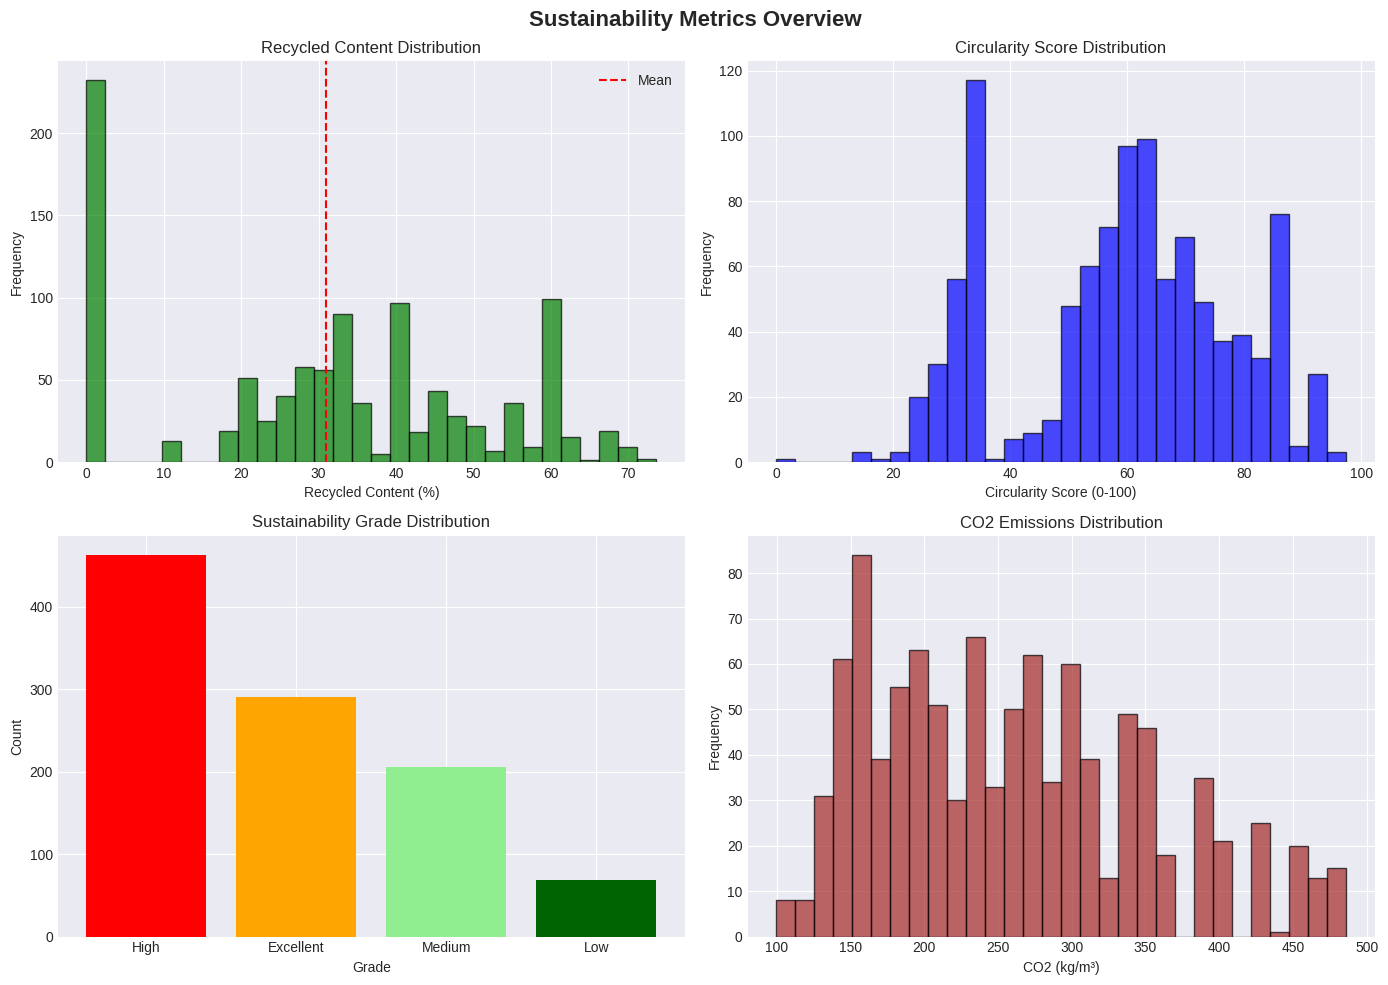

In [9]:
# Sustainability metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sustainability Metrics Overview', fontsize=16, fontweight='bold')

# 1. Recycled Content Distribution
axes[0, 0].hist(df['recycled_content_pct'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Recycled Content Distribution')
axes[0, 0].set_xlabel('Recycled Content (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['recycled_content_pct'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

# 2. Circularity Score Distribution
axes[0, 1].hist(df['circularity_score'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Circularity Score Distribution')
axes[0, 1].set_xlabel('Circularity Score (0-100)')
axes[0, 1].set_ylabel('Frequency')

# 3. Sustainability Grade
grade_counts = df['sustainability_grade'].value_counts()
axes[1, 0].bar(grade_counts.index.astype(str), grade_counts.values, 
               color=['red', 'orange', 'lightgreen', 'darkgreen'])
axes[1, 0].set_title('Sustainability Grade Distribution')
axes[1, 0].set_xlabel('Grade')
axes[1, 0].set_ylabel('Count')

# 4. CO2 Emissions
axes[1, 1].hist(df['estimated_co2_kg_per_m3'], bins=30, color='brown', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('CO2 Emissions Distribution')
axes[1, 1].set_xlabel('CO2 (kg/m³)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

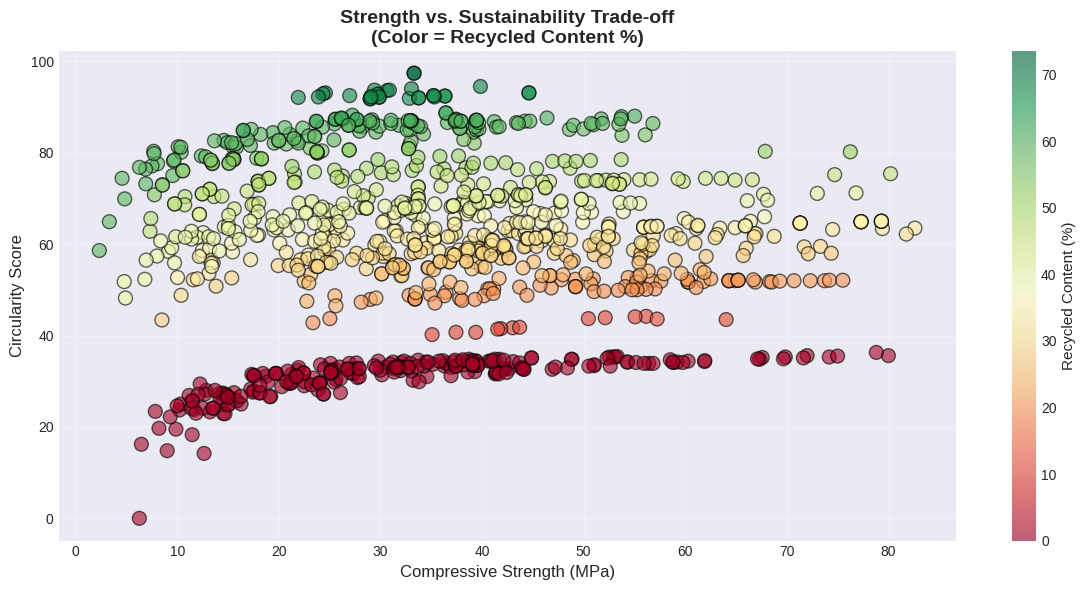

In [10]:
# Strength vs. Sustainability Trade-off
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(df['strength'], df['circularity_score'], 
                    c=df['recycled_content_pct'], cmap='RdYlGn', 
                    s=100, alpha=0.6, edgecolors='black')

ax.set_xlabel('Compressive Strength (MPa)', fontsize=12)
ax.set_ylabel('Circularity Score', fontsize=12)
ax.set_title('Strength vs. Sustainability Trade-off\n(Color = Recycled Content %)', 
             fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Recycled Content (%)', fontsize=11)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

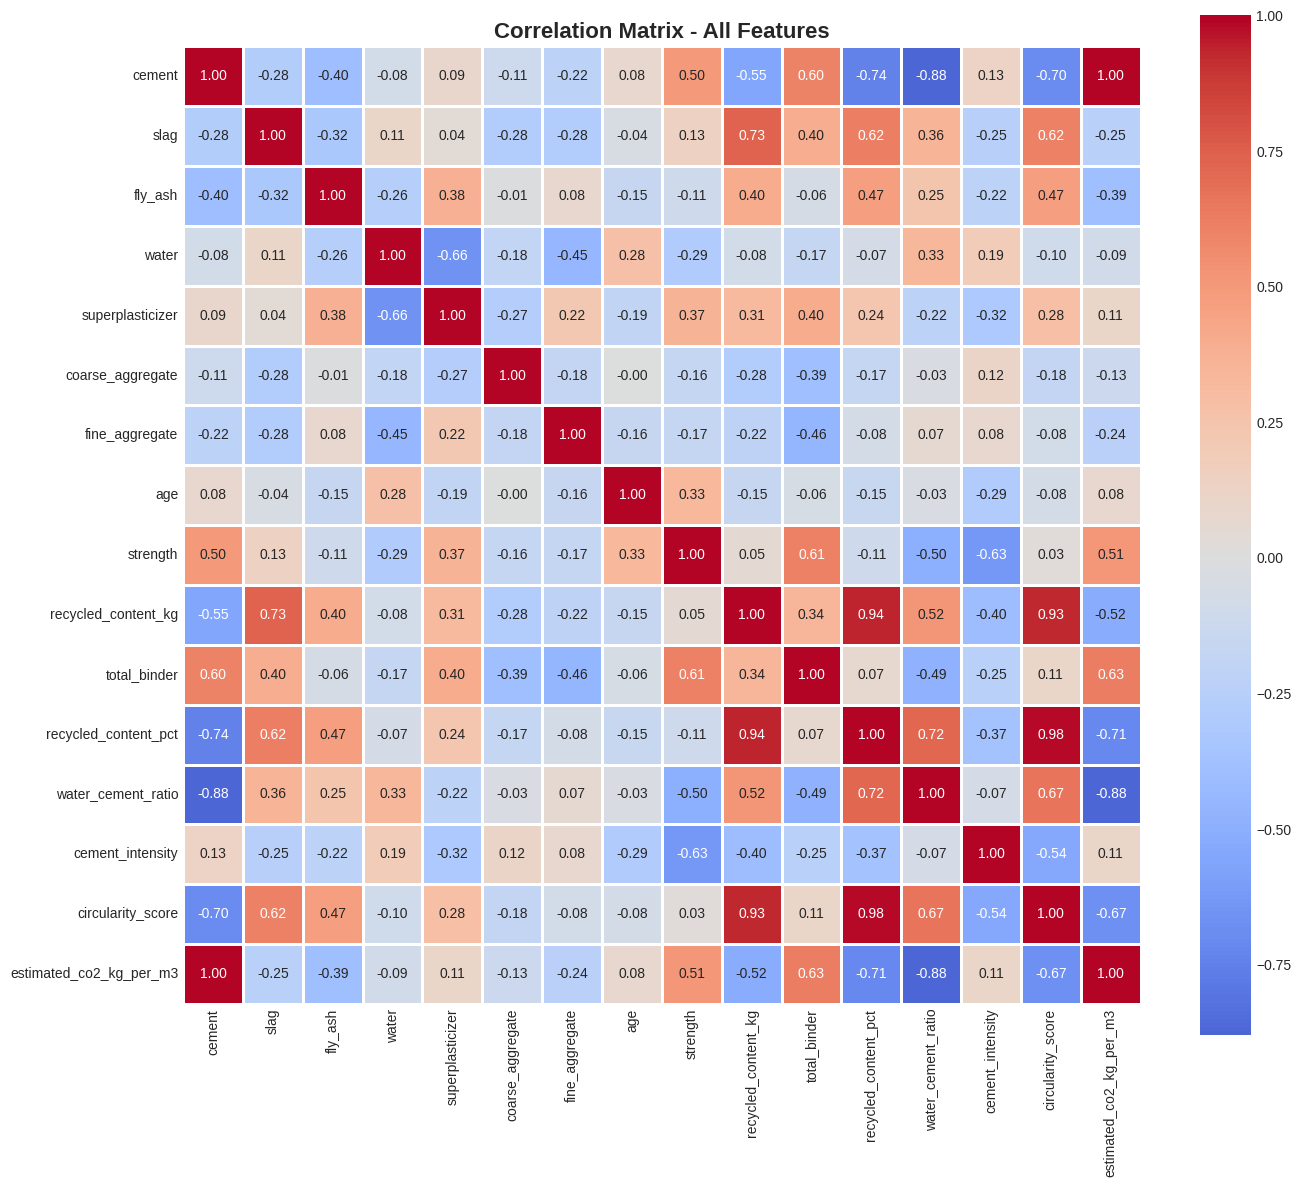

In [11]:
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix - All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Features Correlated with Compressive Strength:
total_binder                  : +0.613
estimated_co2_kg_per_m3       : +0.513
cement                        : +0.498
superplasticizer              : +0.366
age                           : +0.329
slag                          : +0.135
recycled_content_kg           : +0.055
circularity_score             : +0.029
fly_ash                       : -0.106
recycled_content_pct          : -0.107
coarse_aggregate              : -0.165
fine_aggregate                : -0.167
water                         : -0.290
water_cement_ratio            : -0.501
cement_intensity              : -0.631


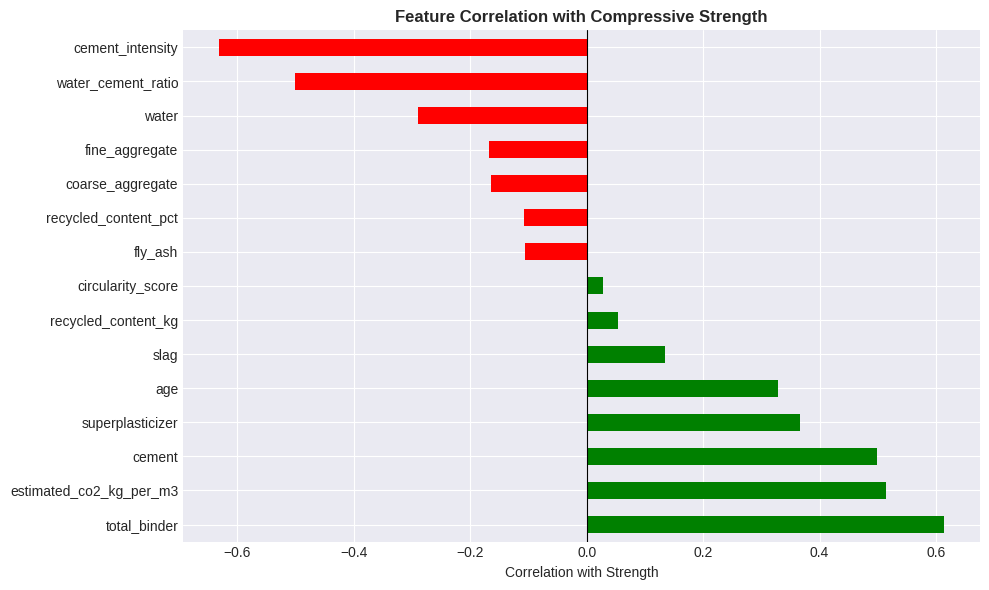

In [12]:
# Strength correlations (most important for ML)
strength_corr = corr_matrix['strength'].sort_values(ascending=False)

print("Features Correlated with Compressive Strength:")
print("="*50)
for feature, corr in strength_corr.items():
    if feature != 'strength':
        print(f"{feature:30s}: {corr:+.3f}")

# Visualize strength correlations
fig, ax = plt.subplots(figsize=(10, 6))
strength_corr_plot = strength_corr.drop('strength')
colors = ['green' if x > 0 else 'red' for x in strength_corr_plot]
strength_corr_plot.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Correlation with Strength')
ax.set_title('Feature Correlation with Compressive Strength', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 6. Key Relationships for ML

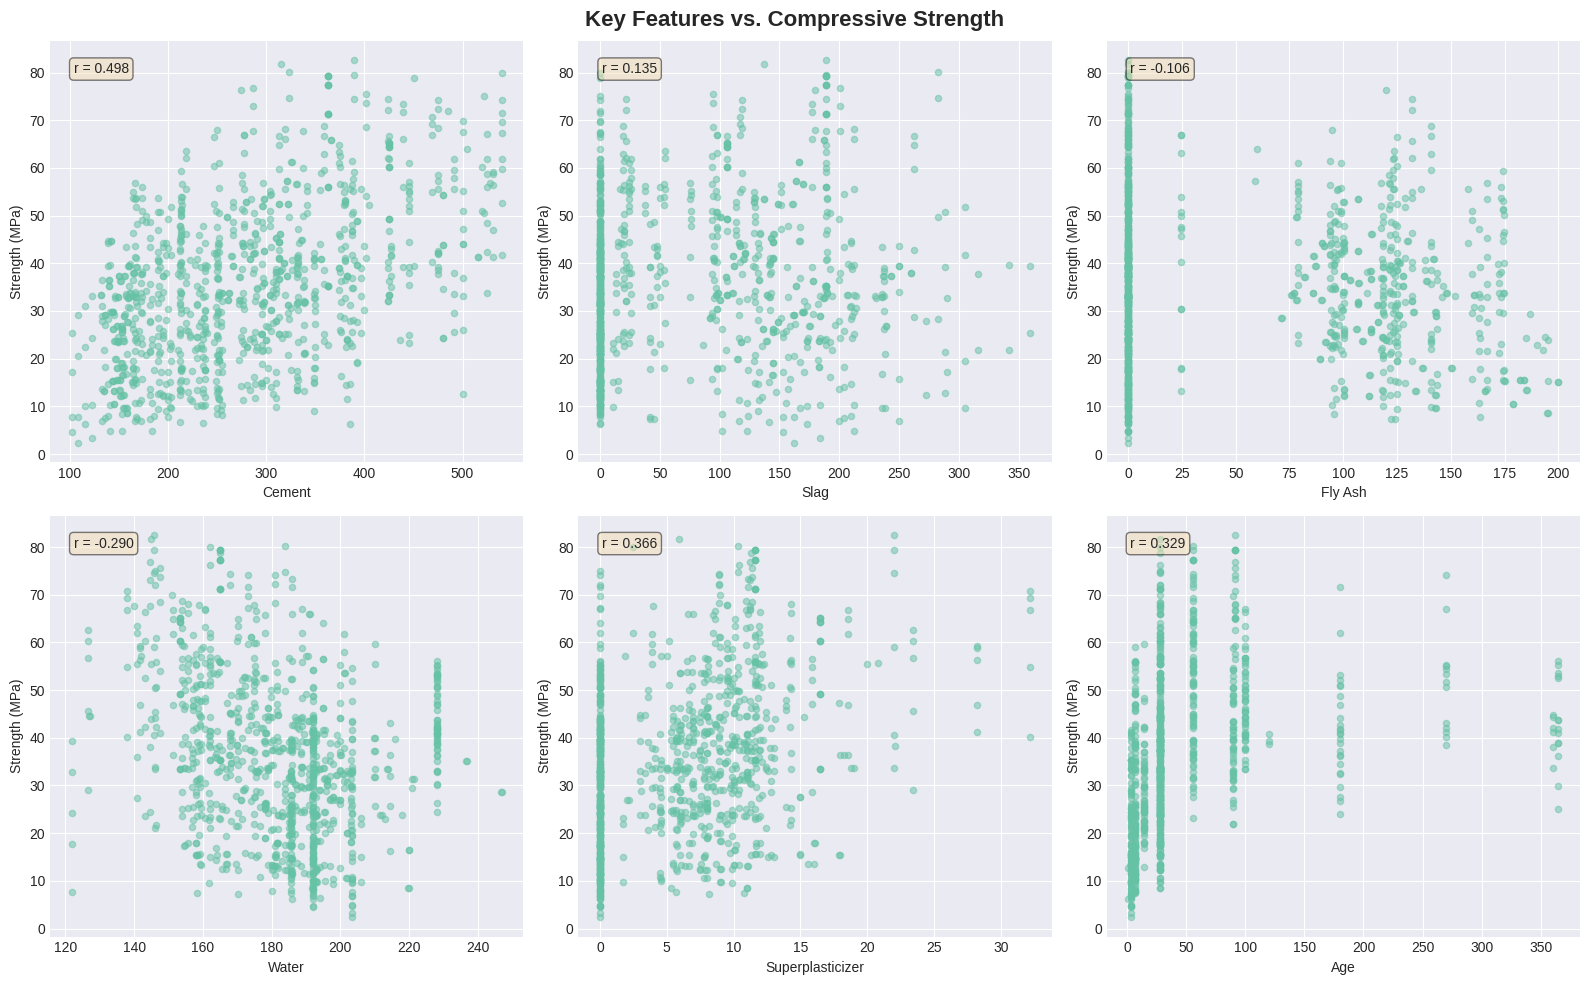

In [13]:
# Most important features for strength prediction
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Key Features vs. Compressive Strength', fontsize=16, fontweight='bold')

top_features = ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'age']

for idx, feature in enumerate(top_features):
    ax = axes[idx // 3, idx % 3]
    ax.scatter(df[feature], df['strength'], alpha=0.5, s=20)
    ax.set_xlabel(feature.replace('_', ' ').title())
    ax.set_ylabel('Strength (MPa)')
    
    # Add correlation value
    corr_val = df[feature].corr(df['strength'])
    ax.text(0.05, 0.95, f'r = {corr_val:.3f}', 
            transform=ax.transAxes, fontsize=10, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 7. Circular Economy Insights

In [14]:
# Analyze high vs low circularity samples
high_circularity = df[df['circularity_score'] >= 70]
low_circularity = df[df['circularity_score'] < 30]

print("CIRCULAR ECONOMY INSIGHTS")
print("="*60)
print(f"\nHigh Circularity Samples (n={len(high_circularity)}):")
print(f"  Avg Recycled Content: {high_circularity['recycled_content_pct'].mean():.1f}%")
print(f"  Avg Strength: {high_circularity['strength'].mean():.1f} MPa")
print(f"  Avg CO2: {high_circularity['estimated_co2_kg_per_m3'].mean():.1f} kg/m³")

print(f"\nLow Circularity Samples (n={len(low_circularity)}):")
print(f"  Avg Recycled Content: {low_circularity['recycled_content_pct'].mean():.1f}%")
print(f"  Avg Strength: {low_circularity['strength'].mean():.1f} MPa")
print(f"  Avg CO2: {low_circularity['estimated_co2_kg_per_m3'].mean():.1f} kg/m³")

print("\n" + "="*60)
print("KEY FINDING: Higher circularity does NOT mean lower strength!")
print("This validates using recycled materials (slag, fly ash) in concrete.")

CIRCULAR ECONOMY INSIGHTS

High Circularity Samples (n=291):
  Avg Recycled Content: 55.8%
  Avg Strength: 32.3 MPa
  Avg CO2: 172.8 kg/m³

Low Circularity Samples (n=70):
  Avg Recycled Content: 0.0%
  Avg Strength: 16.0 MPa
  Avg CO2: 296.2 kg/m³

KEY FINDING: Higher circularity does NOT mean lower strength!
This validates using recycled materials (slag, fly ash) in concrete.


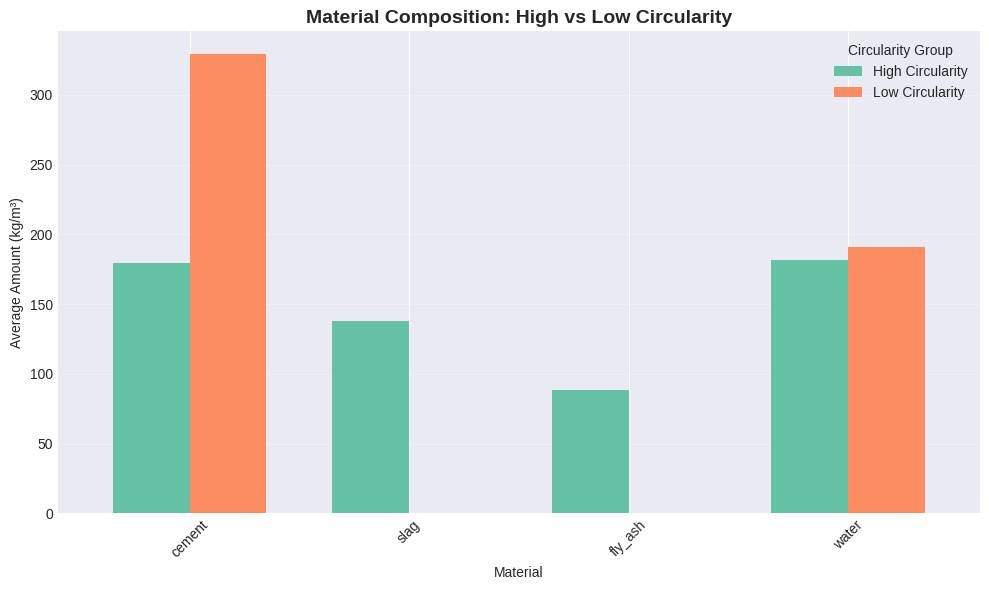


Composition Comparison:
         High Circularity  Low Circularity
cement             179.41           329.07
slag               138.14             0.00
fly_ash             88.73             0.00
water              181.75           190.83


In [15]:
# Compare composition of high vs low circularity
composition_features = ['cement', 'slag', 'fly_ash', 'water']

comparison = pd.DataFrame({
    'High Circularity': high_circularity[composition_features].mean(),
    'Low Circularity': low_circularity[composition_features].mean()
})

comparison.plot(kind='bar', figsize=(10, 6), width=0.7)
plt.title('Material Composition: High vs Low Circularity', fontsize=14, fontweight='bold')
plt.xlabel('Material')
plt.ylabel('Average Amount (kg/m³)')
plt.xticks(rotation=45)
plt.legend(title='Circularity Group')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nComposition Comparison:")
print(comparison)

## 8. Data Quality Checks

In [16]:
# Check for outliers using IQR method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers), (lower, upper)

print("OUTLIER ANALYSIS")
print("="*60)
for col in materials:
    n_outliers, (lower, upper) = detect_outliers(df, col)
    if n_outliers > 0:
        print(f"{col:20s}: {n_outliers:3d} outliers (range: {lower:.1f} - {upper:.1f})")

print("\nNote: Some outliers are expected in materials data due to")
print("different concrete formulations and applications.")

OUTLIER ANALYSIS
slag                :   2 outliers (range: -214.4 - 357.4)
water               :   9 outliers (range: 124.3 - 232.6)
superplasticizer    :  10 outliers (range: -15.3 - 25.5)
fine_aggregate      :   5 outliers (range: 591.4 - 963.6)
age                 :  59 outliers (range: -66.5 - 129.5)

Note: Some outliers are expected in materials data due to
different concrete formulations and applications.


## 9. Feature Engineering Ideas

In [17]:
print("FEATURE ENGINEERING OPPORTUNITIES")
print("="*60)

# 1. Interaction features
print("\n1. INTERACTION FEATURES:")
print("   - cement × water (hydration potential)")
print("   - (slag + fly_ash) × age (pozzolanic reaction)")
print("   - cement / (slag + fly_ash) (binder ratio)")

# 2. Polynomial features
print("\n2. POLYNOMIAL FEATURES:")
print("   - age² (non-linear strength gain)")
print("   - cement² (quadratic relationship)")

# 3. Ratio features
print("\n3. RATIO FEATURES:")
print("   - water/cement ratio ✓ (already created)")
print("   - superplasticizer/cement ratio")
print("   - fine/coarse aggregate ratio")

# 4. Binning
print("\n4. CATEGORICAL FEATURES:")
print("   - age_category (early/medium/late curing)")
print("   - strength_category (low/medium/high)")
print("   - recycled_content_category (none/low/medium/high)")

print("\n" + "="*60)

FEATURE ENGINEERING OPPORTUNITIES

1. INTERACTION FEATURES:
   - cement × water (hydration potential)
   - (slag + fly_ash) × age (pozzolanic reaction)
   - cement / (slag + fly_ash) (binder ratio)

2. POLYNOMIAL FEATURES:
   - age² (non-linear strength gain)
   - cement² (quadratic relationship)

3. RATIO FEATURES:
   - water/cement ratio ✓ (already created)
   - superplasticizer/cement ratio
   - fine/coarse aggregate ratio

4. CATEGORICAL FEATURES:
   - age_category (early/medium/late curing)
   - strength_category (low/medium/high)
   - recycled_content_category (none/low/medium/high)



## 10. Key Insights & Recommendations

In [18]:
print("\n" + "="*60)
print("KEY INSIGHTS FROM DATA EXPLORATION")
print("="*60)

print("\n📊 DATASET CHARACTERISTICS:")
print(f"   • {len(df)} samples with 8 material inputs")
print(f"   • Target: Compressive strength (range: {df['strength'].min():.1f}-{df['strength'].max():.1f} MPa)")
print(f"   • No missing values - clean dataset")
print(f"   • Some outliers present (expected for diverse formulations)")

print("\n♻️ SUSTAINABILITY FINDINGS:")
print(f"   • Average recycled content: {df['recycled_content_pct'].mean():.1f}%")
print(f"   • {len(df[df['recycled_content_pct'] > 50])} samples with >50% recycled content")
print(f"   • Higher recycled content does NOT reduce strength significantly")
print(f"   • CO2 emissions range: {df['estimated_co2_kg_per_m3'].min():.0f}-{df['estimated_co2_kg_per_m3'].max():.0f} kg/m³")

print("\n🔬 ML MODELING INSIGHTS:")
print("   • Cement shows strongest correlation with strength (+{:.3f})".format(df['cement'].corr(df['strength'])))
print("   • Age is important for strength development")
print("   • Water shows negative correlation (higher water = lower strength)")
print("   • Non-linear relationships suggest tree-based models or neural networks")

print("\n🎯 RECOMMENDATIONS FOR ML MODELS:")
print("   1. Start with Random Forest (handles non-linearity well)")
print("   2. Try XGBoost for better performance")
print("   3. Feature engineering: interaction terms, ratios")
print("   4. Consider ensemble methods")
print("   5. Multi-task learning: predict strength AND circularity")

print("\n🌱 CIRCULAR ECONOMY OPPORTUNITIES:")
print("   • Optimize for high strength + high recycled content")
print("   • Use slag and fly ash as cement replacement")
print("   • Develop recommendation system for sustainable formulations")

print("\n" + "="*60)
print("NEXT STEPS: Notebook 02 - Baseline ML Models")
print("="*60 + "\n")


KEY INSIGHTS FROM DATA EXPLORATION

📊 DATASET CHARACTERISTICS:
   • 1030 samples with 8 material inputs
   • Target: Compressive strength (range: 2.3-82.6 MPa)
   • No missing values - clean dataset
   • Some outliers present (expected for diverse formulations)

♻️ SUSTAINABILITY FINDINGS:
   • Average recycled content: 31.0%
   • 197 samples with >50% recycled content
   • Higher recycled content does NOT reduce strength significantly
   • CO2 emissions range: 99-486 kg/m³

🔬 ML MODELING INSIGHTS:
   • Cement shows strongest correlation with strength (+0.498)
   • Age is important for strength development
   • Water shows negative correlation (higher water = lower strength)
   • Non-linear relationships suggest tree-based models or neural networks

🎯 RECOMMENDATIONS FOR ML MODELS:
   1. Start with Random Forest (handles non-linearity well)
   2. Try XGBoost for better performance
   3. Feature engineering: interaction terms, ratios
   4. Consider ensemble methods
   5. Multi-task lea

## Summary Statistics Export

In [20]:
# Export key findings for documentation
summary_stats = {
    'Dataset Size': len(df),
    'Features': len(df.columns),
    'Avg Strength (MPa)': df['strength'].mean(),
    'Avg Recycled Content (%)': df['recycled_content_pct'].mean(),
    'Avg Circularity Score': df['circularity_score'].mean(),
    'Avg CO2 (kg/m3)': df['estimated_co2_kg_per_m3'].mean(),
    'High Sustainability Samples': len(df[df['sustainability_grade'].isin(['High', 'Excellent'])]),
    'Samples with >50% Recycled': len(df[df['recycled_content_pct'] > 50])
}

summary_df = pd.DataFrame([summary_stats]).T
summary_df.columns = ['Value']
summary_df.to_csv('../data/processed/exploration_summary.csv')

print("✓ Summary statistics exported to data/processed/exploration_summary.csv")
print("\nDataset exploration complete! 🎉")

✓ Summary statistics exported to data/processed/exploration_summary.csv

Dataset exploration complete! 🎉
